<a href="https://colab.research.google.com/github/sambhav121/assingment-03-bitsom_ba_2511293_Part4/blob/main/Part4_Visualisation_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Task 1: Data Exploration

with open("students.csv", "w") as f:
  f.write("""name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
""")

import pandas as pd

# 1. Load dataset
df = pd.read_csv("students.csv")

# 2. First 5 rows
print(df.head())

# 3. Shape and data types
print("Shape:", df.shape)
print(df.dtypes)

# 4. Summary statistics
print(df.describe())

# 5. Pass/Fail count
print(df["passed"].value_counts())

# 6. Average score per subject (pass vs fail)
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Pass Avg:\n", pass_avg)
print("Fail Avg:\n", fail_avg)

# 7. Highest overall average student
df["avg_temp"] = df[subject_cols].mean(axis=1)

top_student = df.loc[df["avg_temp"].idxmax()]
print("Top student:", top_student["name"], top_student["avg_temp"])

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
Shape: (15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pct  \
count  15.0

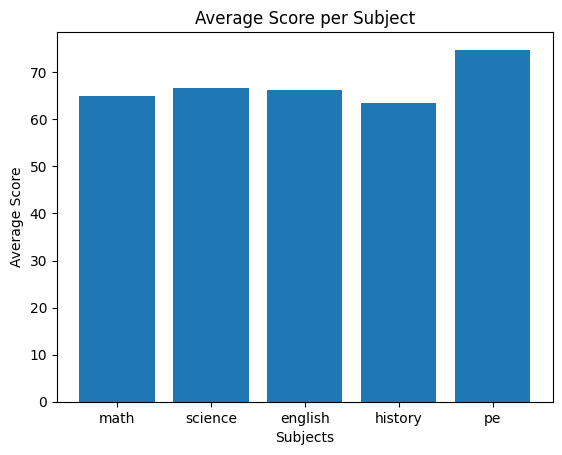

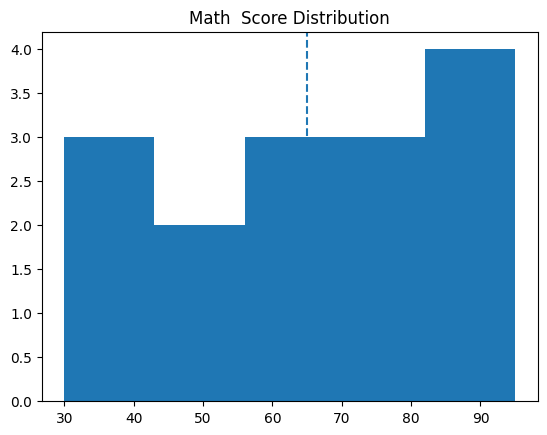

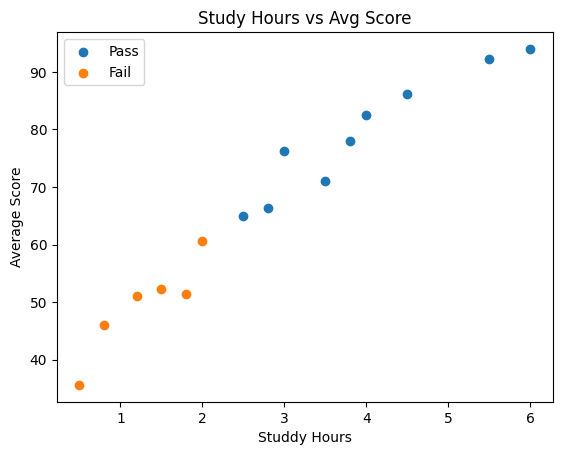

/tmp/ipykernel_6966/2867556634.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])


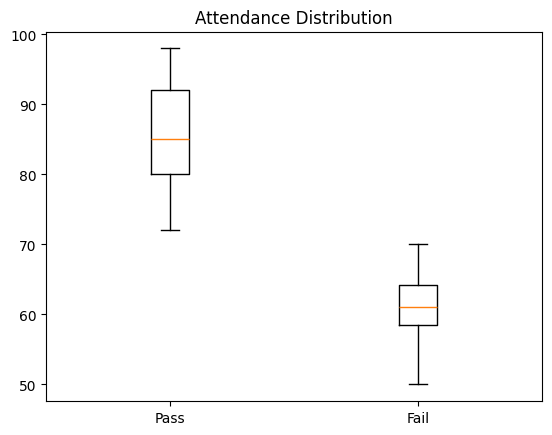

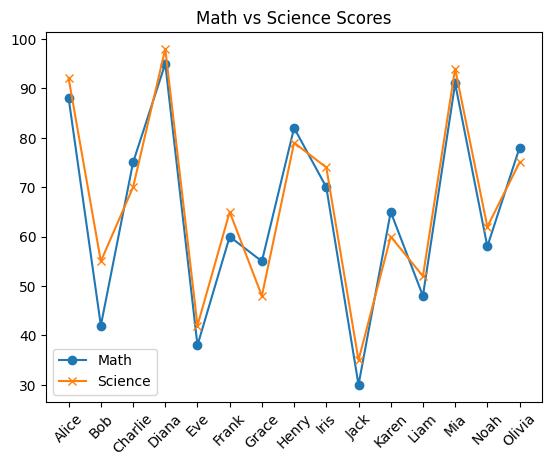

In [2]:
# Task 2: Matplotlib

with open("students.csv", "w") as f:
  f.write("""name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
""")

import matplotlib.pyplot as plt

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Bar Chart
avg_score = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_score)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1 bar.png")
plt.show()

# 2. Historgram
plt.figure()
plt.hist(df["math"], bins=5)
mean_math = df["math"].mean()
plt.axvline(mean_math, linestyle="--")
plt.title("Math  Score Distribution")
plt.savefig("plot2_hist.png")
plt.show()

# 3. Scatter plot
plt.figure()

pass_df = df[df["passed"] == 1]
fail_df = df[df["passed"] == 0]

plt.scatter(pass_df["study_hours_per_day"], pass_df["avg_score"], label="Pass")
plt.scatter(fail_df["study_hours_per_day"], fail_df["avg_score"], label="Fail")

plt.xlabel("Studdy Hours")
plt.ylabel("Average Score")
plt.legend()
plt.title("Study Hours vs Avg Score")
plt.savefig("plot3_scatter.png")
plt.show()

# 4. Box Plot
pass_att = pass_df["attendance_pct"].tolist()
fail_att = fail_df["attendance_pct"].tolist()

plt.figure()
plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])
plt.title("Attendance Distribution")
plt.savefig("plot4_box.png")
plt.show()

# 5. Line Plot
plt.figure()

plt.plot(df["name"], df["math"], marker="o", label="Math")
plt.plot(df["name"], df["science"], marker="x", label="Science")

plt.xticks(rotation=45)
plt.legend()
plt.title("Math vs Science Scores")
plt.savefig("plot5_line.png")
plt.show()

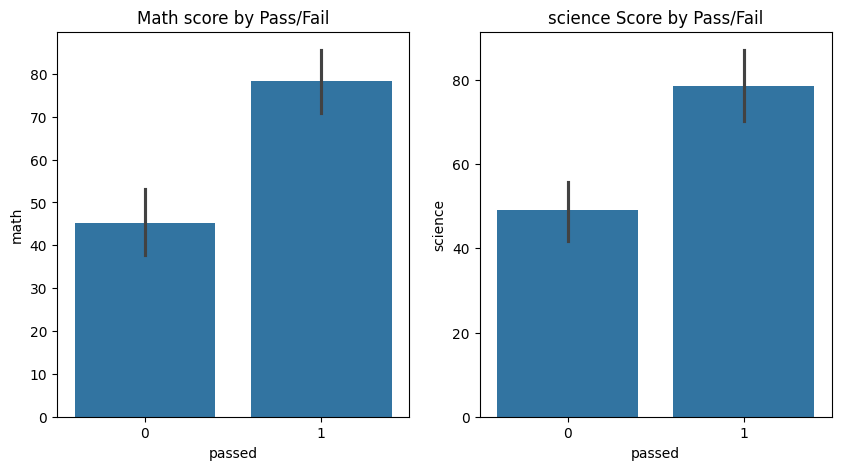

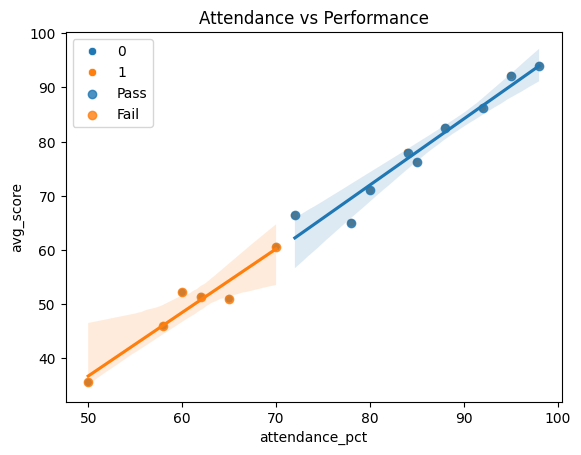

In [3]:
with open("students.csv", "w") as f:
  f.write("""name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
""")

import seaborn as sns

# Bar plots
plt.figure(figsize=(10,5))

ax1 = plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math score by Pass/Fail")

ax2 = plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("science Score by Pass/Fail")

plt.savefig("plot6_seaborn_bar.png")
plt.show()


# Scatter + Regression
plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label="Pass")
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label="Fail")

plt.legend()
plt.title("Attendance vs Performance")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# Comment
#Seaborn is easier for statistical plot and cleanervisuals.
#Matplotlib requires more manual customization but gives more control.

Test Accuracy: 1.0

Predictions:
Jack | Actual: 0 | Pred: 0 ✅ Correct
Liam | Actual: 0 | Pred: 0 ✅ Correct
Alice | Actual: 1 | Pred: 1 ✅ Correct

Feature Importance:
english : 0.8125127982724648
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155
pe : 0.47497406284967797
math : 0.43794393086873595
science : 0.3230097624690249
history : 0.26292892629062437


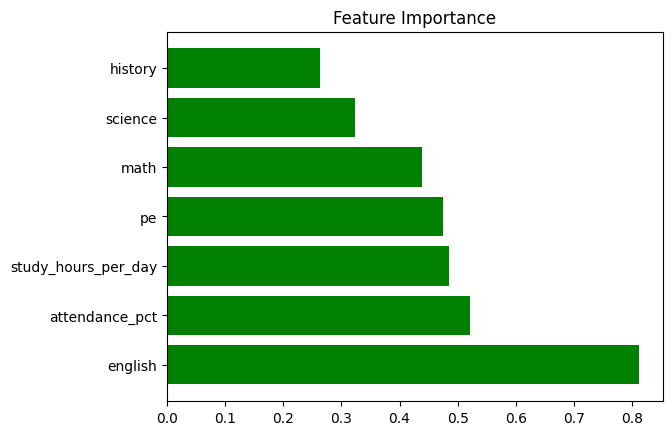


New Student Prediction: Pass
probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:
with open("students.csv", "w") as f:
  f.write("""name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
""")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")

#Features & Target
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Test accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Detailed output
print("\nPredictions:")
for i in range(len(X_test)):
    name = df.loc[X_test.index[i], 'name']
    actual = y_test.iloc[i]
    pred = y_pred[i]
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(name, "| Actual:", actual, "| Pred:",pred, status)

# Feature Importance
coefficients = model.coef_[0]
features = X.columns

importance = list(zip(features, coefficients))
importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:")
for f, c in importance:
    print(f, ":", c)

# Plot coefficients
plt.figure()
values = [c for f,c in importance]
labels = [f for f,c in importance]

colors = ['green' if v > 0 else 'red' for v in values]

plt.barh(labels, values, color=colors)
plt.title("Feature Importance")
plt.savefig("plot8_feature_importance.png")
plt.show()

# Bonus - New student prediction
new_student = [[75,70,68,65,80,82,3.2]]
new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("\nNew Student Prediction:", "Pass" if prediction[0]==1 else "Fail")
print("probability:", prob)

In [7]:
from google.colab import files
files.download("plot1 bar.png")
files.download("plot2_hist.png")
files.download("plot3_scatter.png")
files.download("plot4_box.png")
files.download("plot5_line.png")
files.download("plot6_seaborn_bar.png")
files.download("plot7_seaborn_scatter.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
from google.colab import files
files.download("students.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>